✅ Loaded bitcoin_preprocessed_daily.csv with shape (5063, 10)
🗂 Using DATE_COL='Timestamp', VALUE_COL='Open'
✅ Frequency: D
📊 Train=4050, Test=1013, Horizon=1013
✅ ARIMA trained
✅ SARIMA trained


18:47:00 - cmdstanpy - INFO - Chain [1] start processing
18:47:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet trained
✅ LSTM trained

📈 Model Performance:
     Model           MAE          RMSE       MAPE
0    arima  39574.219288  49623.681575  49.281375
1   sarima  39563.099785  49613.973521  49.260948
2  prophet  42200.595807  53740.233035  51.890553
3     lstm  27948.810857  32889.220425  67.035041

💾 Forecasts saved to model_forecast.csv


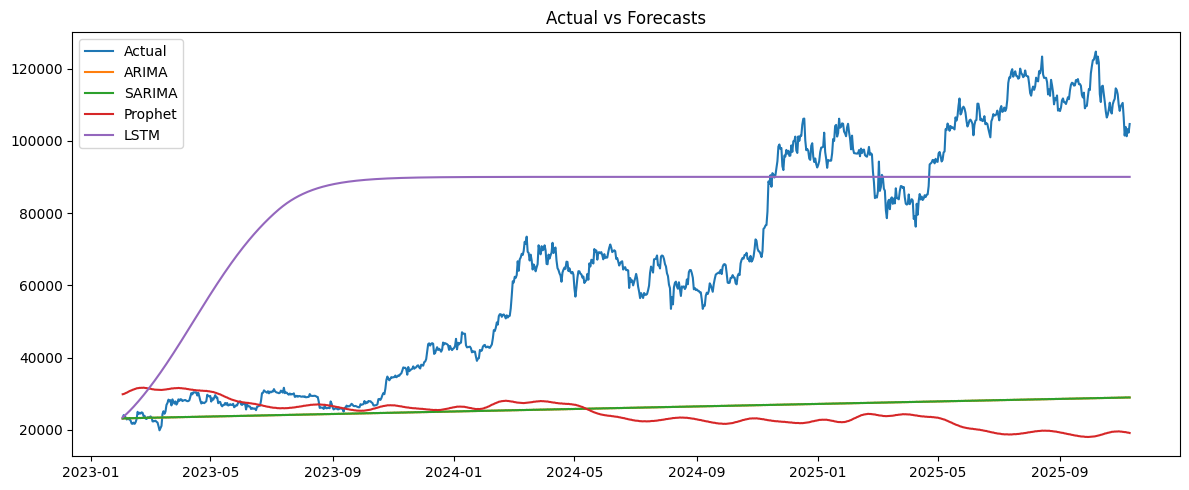

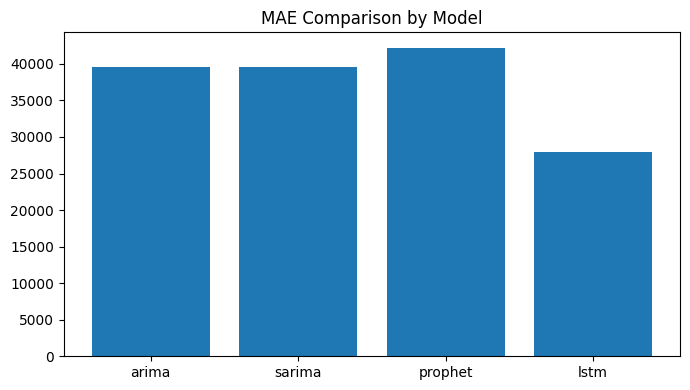

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, os
from pathlib import Path

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional models
try:
    from prophet import Prophet
    have_prophet = True
except Exception:
    have_prophet = False
    print("⚠️ Prophet not installed. Install with: pip install prophet")

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    have_tf = True
except Exception:
    have_tf = False
    print("⚠️ TensorFlow not installed. Install with: pip install tensorflow")


# -------------------- CONFIG --------------------
INPUT_FILE = "bitcoin_preprocessed_daily.csv"     # <-- replace with your CSV filename
DATE_COL = None             # auto-detect if None
VALUE_COL = None            # auto-detect if None
TRAIN_RATIO = 0.8
LOOK_BACK = 14
LSTM_EPOCHS = 40
LSTM_BATCH = 16

# -------------------- LOAD DATA --------------------
def load_or_simulate(path):
    if Path(path).exists():
        df = pd.read_csv(path)
        print(f"✅ Loaded {path} with shape {df.shape}")
    else:
        print(f"⚠️ File '{path}' not found — using simulated time series for demo.")
        rng = pd.date_range(end=pd.Timestamp.today(), periods=150, freq='D')
        np.random.seed(42)
        series = np.cumsum(np.random.randn(len(rng)) * 2 + 0.5) + 50
        df = pd.DataFrame({"date": rng, "value": series})
    return df

df = load_or_simulate(INPUT_FILE)

# Auto-detect date/value columns
if DATE_COL is None:
    for c in df.columns:
        if 'date' in c.lower() or 'time' in c.lower() or c.lower() == 'ds':
            DATE_COL = c
            break
if VALUE_COL is None:
    VALUE_COL = [c for c in df.columns if c != DATE_COL and np.issubdtype(df[c].dtype, np.number)][0]

print(f"🗂 Using DATE_COL='{DATE_COL}', VALUE_COL='{VALUE_COL}'")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df[[DATE_COL, VALUE_COL]].sort_values(DATE_COL).reset_index(drop=True)
df.columns = ["ds", "y"]
df["y"] = pd.to_numeric(df["y"], errors="coerce").interpolate().bfill()

# Ensure daily frequency
if pd.infer_freq(df["ds"]) is None:
    df = df.set_index("ds").asfreq("D").interpolate().reset_index()
print(f"✅ Frequency: {pd.infer_freq(df['ds']) or 'Daily (interpolated)'}")

# -------------------- TRAIN/TEST SPLIT --------------------
n = len(df)
train_size = int(n * TRAIN_RATIO)
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]
H = len(test_df)
print(f"📊 Train={len(train_df)}, Test={len(test_df)}, Horizon={H}")

# -------------------- ARIMA --------------------
def fit_arima(train):
    best_aic, best_model = np.inf, None
    for p in range(3):
        for d in range(3):
            for q in range(3):
                try:
                    m = ARIMA(train, order=(p,d,q)).fit()
                    if m.aic < best_aic:
                        best_aic, best_model = m.aic, m
                except: pass
    return best_model

arima_model = fit_arima(train_df["y"])
arima_pred = arima_model.forecast(steps=H)
print("✅ ARIMA trained")

# -------------------- SARIMA --------------------
sarima_model = SARIMAX(train_df["y"], order=(1,1,1), seasonal_order=(1,1,1,7)).fit(disp=False)
sarima_pred = sarima_model.forecast(H)
print("✅ SARIMA trained")

# -------------------- Prophet --------------------
if have_prophet:
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    m.fit(train_df)
    future = m.make_future_dataframe(periods=H)
    prophet_pred = m.predict(future).iloc[-H:]["yhat"]
    print("✅ Prophet trained")
else:
    prophet_pred = pd.Series(np.linspace(train_df["y"].iloc[-1], train_df["y"].iloc[-1], H))

# -------------------- LSTM --------------------
if have_tf:
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df[["y"]])
    
    def create_seq(data, step=LOOK_BACK):
        X, y = [], []
        for i in range(len(data)-step):
            X.append(data[i:i+step])
            y.append(data[i+step])
        return np.array(X), np.array(y)
    
    X_train, y_train = create_seq(train_scaled)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    model = Sequential([
        LSTM(50, activation='relu', input_shape=(LOOK_BACK,1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH, verbose=0)
    
    # Forecast
    last_seq = train_scaled[-LOOK_BACK:]
    lstm_forecast = []
    for _ in range(H):
        pred = model.predict(last_seq.reshape(1, LOOK_BACK, 1), verbose=0)
        lstm_forecast.append(pred[0,0])
        last_seq = np.append(last_seq[1:], pred)
    lstm_pred = scaler.inverse_transform(np.array(lstm_forecast).reshape(-1,1)).flatten()
    print("✅ LSTM trained")
else:
    lstm_pred = np.repeat(train_df["y"].iloc[-1], H)

# -------------------- COMBINE RESULTS --------------------
results = pd.DataFrame({
    "ds": test_df["ds"].values,
    "actual": test_df["y"].values,
    "arima": arima_pred.values,
    "sarima": sarima_pred.values,
    "prophet": prophet_pred.values,
    "lstm": lstm_pred
}).fillna(method='ffill')

# -------------------- METRICS --------------------
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = []
for col in ["arima","sarima","prophet","lstm"]:
    mae = mean_absolute_error(results["actual"], results[col])
    rmse = math.sqrt(mean_squared_error(results["actual"], results[col]))
    map_err = mape(results["actual"], results[col])
    metrics.append([col, mae, rmse, map_err])

metrics_df = pd.DataFrame(metrics, columns=["Model","MAE","RMSE","MAPE"])
print("\n📈 Model Performance:")
print(metrics_df)

# -------------------- SAVE --------------------
results.to_csv("model_forecast.csv", index=False)
print("\n💾 Forecasts saved to model_forecast.csv")

# -------------------- PLOTS --------------------
plt.figure(figsize=(12,5))
plt.plot(results["ds"], results["actual"], label="Actual")
plt.plot(results["ds"], results["arima"], label="ARIMA")
plt.plot(results["ds"], results["sarima"], label="SARIMA")
plt.plot(results["ds"], results["prophet"], label="Prophet")
plt.plot(results["ds"], results["lstm"], label="LSTM")
plt.legend(); plt.title("Actual vs Forecasts"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.bar(metrics_df["Model"], metrics_df["MAE"])
plt.title("MAE Comparison by Model"); plt.tight_layout(); plt.show()

In [3]:
pip install ace_tools

Note: you may need to restart the kernel to use updated packages.


Training ARIMA...
Training SARIMA...
Training Prophet...


19:22:28 - cmdstanpy - INFO - Chain [1] start processing
19:22:31 - cmdstanpy - INFO - Chain [1] done processing


Training LSTM...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

✅ model_forecast.csv saved successfully for Power BI!


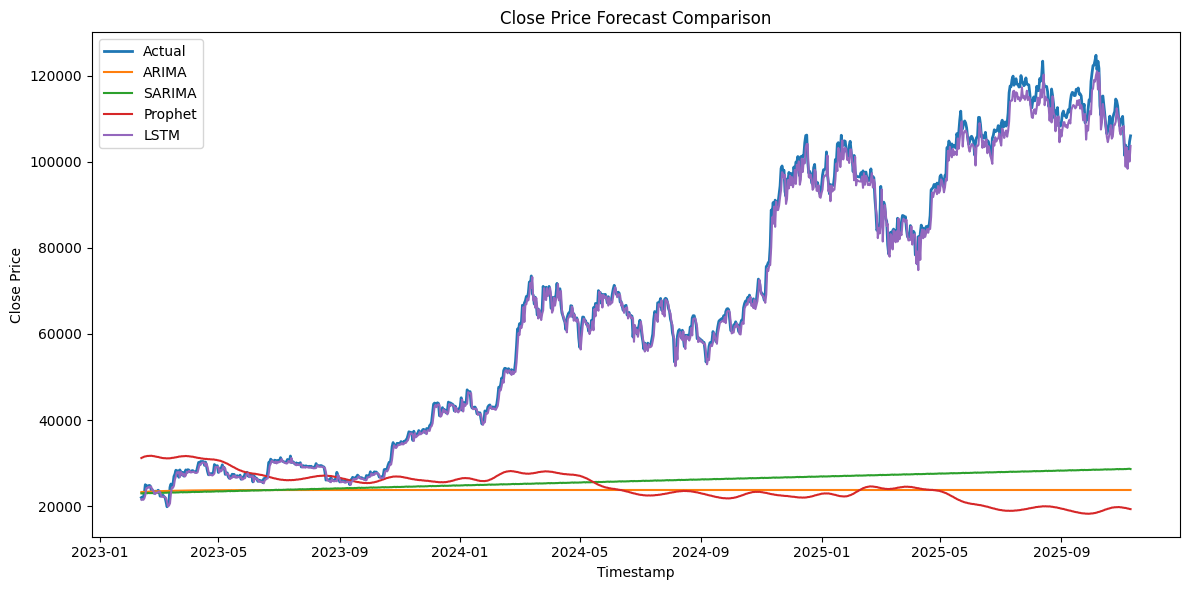

In [18]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Time-series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Deep learning
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------------------------------------------
# 1️⃣ Load and Prepare Dataset
# -------------------------------------------------------------
FILE_PATH = 'bitcoin_preprocessed_daily.csv'  # Replace with your CSV file path
TARGET_COLUMN = 'Close'         # We'll forecast the closing price
DATE_COLUMN = 'Timestamp'

# Load CSV
data = pd.read_csv(FILE_PATH)

# Parse date column
data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN])
data.sort_values(DATE_COLUMN, inplace=True)

# Select only Timestamp and Close
data = data[[DATE_COLUMN, TARGET_COLUMN]].dropna()
data.set_index(DATE_COLUMN, inplace=True)

# Train-test split (80-20)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# -------------------------------------------------------------
# 2️⃣ ARIMA Model
# -------------------------------------------------------------
print("Training ARIMA...")
try:
    arima_model = ARIMA(train, order=(2, 1, 2))
    arima_result = arima_model.fit()
    arima_forecast = arima_result.forecast(steps=len(test))
except Exception as e:
    print("ARIMA failed:", e)
    arima_forecast = pd.Series([np.nan] * len(test), index=test.index)

# -------------------------------------------------------------
# 3️⃣ SARIMA Model
# -------------------------------------------------------------
print("Training SARIMA...")
try:
    sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    sarima_result = sarima_model.fit(disp=False)
    sarima_forecast = sarima_result.forecast(steps=len(test))
except Exception as e:
    print("SARIMA failed:", e)
    sarima_forecast = pd.Series([np.nan] * len(test), index=test.index)

# -------------------------------------------------------------
# 4️⃣ Prophet Model
# -------------------------------------------------------------
print("Training Prophet...")
prophet_df = data.reset_index().rename(columns={DATE_COLUMN: 'ds', TARGET_COLUMN: 'y'})
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet()
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test))
forecast_prophet = prophet_model.predict(future)
prophet_forecast = forecast_prophet[['ds', 'yhat']].set_index('ds').iloc[-len(test):]

# -------------------------------------------------------------
# 5️⃣ LSTM Model
# -------------------------------------------------------------
print("Training LSTM...")
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

def create_sequences(data, look_back=10):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

LOOK_BACK = 10
X_train, y_train = create_sequences(scaled_train, LOOK_BACK)
X_test, y_test = create_sequences(scaled_test, LOOK_BACK)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(LOOK_BACK, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)

lstm_pred_scaled = lstm_model.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_pred_scaled)

# Align LSTM forecast with test dates
lstm_forecast_series = pd.Series(lstm_forecast.flatten(), index=test.index[LOOK_BACK:])

# -------------------------------------------------------------
# 6️⃣ Combine All Forecasts
# -------------------------------------------------------------
forecast_df = pd.DataFrame({
    'Timestamp': test.index,
    'Actual_Close': test[TARGET_COLUMN].values,
    'ARIMA_Forecast': arima_forecast.values,
    'SARIMA_Forecast': sarima_forecast.values,
    'Prophet_Forecast': prophet_forecast['yhat'].values
})

# Adjust for LSTM shorter forecast
forecast_df = forecast_df.iloc[LOOK_BACK:]
forecast_df['LSTM_Forecast'] = lstm_forecast_series.values

# -------------------------------------------------------------
# 7️⃣ Save to CSV for Power BI
# -------------------------------------------------------------
forecast_df.to_csv('model_forecast.csv', index=False)
print("\n✅ model_forecast.csv saved successfully for Power BI!")

# -------------------------------------------------------------
# 8️⃣ Plot Forecast Comparison
# -------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(forecast_df['Timestamp'], forecast_df['Actual_Close'], label='Actual', linewidth=2)
plt.plot(forecast_df['Timestamp'], forecast_df['ARIMA_Forecast'], label='ARIMA')
plt.plot(forecast_df['Timestamp'], forecast_df['SARIMA_Forecast'], label='SARIMA')
plt.plot(forecast_df['Timestamp'], forecast_df['Prophet_Forecast'], label='Prophet')
plt.plot(forecast_df['Timestamp'], forecast_df['LSTM_Forecast'], label='LSTM')
plt.title('Close Price Forecast Comparison')
plt.xlabel('Timestamp')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

Importing plotly failed. Interactive plots will not work.


Training ARIMA...


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Training SARIMA...


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Training Prophet...


19:41:38 - cmdstanpy - INFO - Chain [1] start processing
19:41:39 - cmdstanpy - INFO - Chain [1] done processing


Training LSTM...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

✅ model_forecast.csv and model_metrics.csv saved successfully!


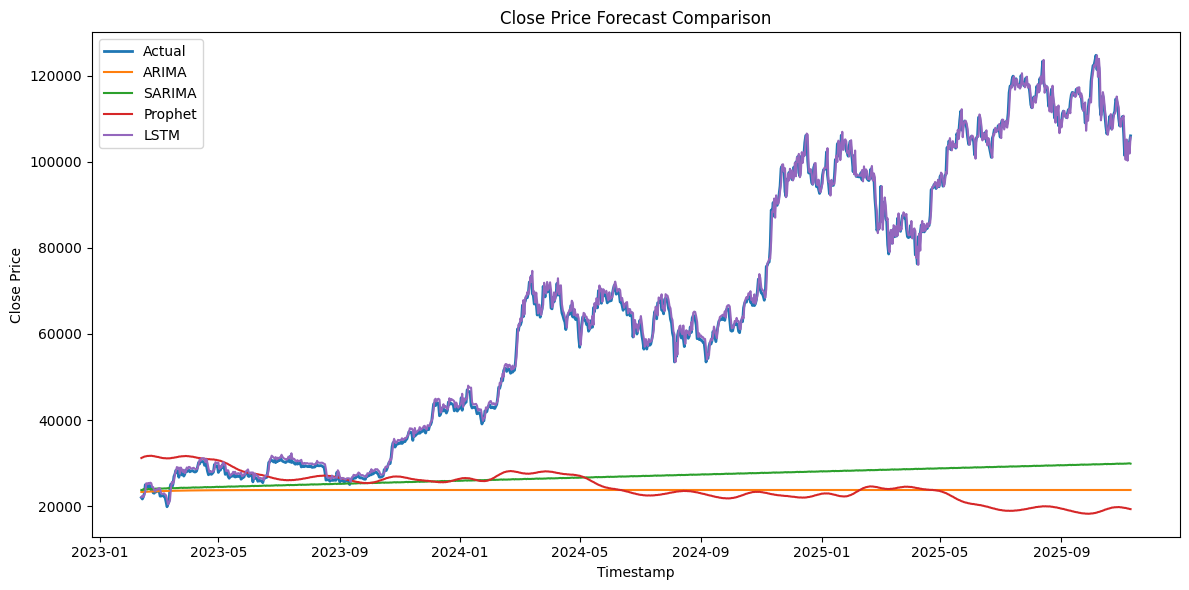


📊 Model Performance Metrics:
     Model        RMSE         MAE
0    ARIMA  52755.2651  42399.3627
1   SARIMA  49206.9007  39203.5311
2  Prophet  53935.1593  42510.6946
3     LSTM   1779.5377   1314.8186


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Deep learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------------------------------------------
# 1️⃣ Load and Prepare Dataset
# -------------------------------------------------------------
FILE_PATH = 'bitcoin_preprocessed_daily.csv'   # change this to your dataset path
TARGET_COLUMN = 'Close'
DATE_COLUMN = 'Timestamp'

data = pd.read_csv(FILE_PATH)
data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN])
data.sort_values(DATE_COLUMN, inplace=True)

# select Timestamp and Close
data = data[[DATE_COLUMN, TARGET_COLUMN]].dropna()
data.set_index(DATE_COLUMN, inplace=True)

# Train-Test split (80/20)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# -------------------------------------------------------------
# 2️⃣ ARIMA Model
# -------------------------------------------------------------
print("Training ARIMA...")
try:
    arima_model = ARIMA(train, order=(2, 1, 2))
    arima_result = arima_model.fit()
    arima_forecast = arima_result.forecast(steps=len(test))
except Exception as e:
    print("ARIMA failed:", e)
    arima_forecast = pd.Series([np.nan] * len(test), index=test.index)

# -------------------------------------------------------------
# 3️⃣ SARIMA Model
# -------------------------------------------------------------
print("Training SARIMA...")
try:
    sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    sarima_result = sarima_model.fit(disp=False)
    sarima_forecast = sarima_result.forecast(steps=len(test))
except Exception as e:
    print("SARIMA failed:", e)
    sarima_forecast = pd.Series([np.nan] * len(test), index=test.index)

# -------------------------------------------------------------
# 4️⃣ Prophet Model
# -------------------------------------------------------------
print("Training Prophet...")
prophet_df = data.reset_index().rename(columns={DATE_COLUMN: 'ds', TARGET_COLUMN: 'y'})
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet()
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test))
forecast_prophet = prophet_model.predict(future)
prophet_forecast = forecast_prophet[['ds', 'yhat']].set_index('ds').iloc[-len(test):]

# -------------------------------------------------------------
# 5️⃣ LSTM Model
# -------------------------------------------------------------
print("Training LSTM...")
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

def create_sequences(data, look_back=10):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

LOOK_BACK = 10
X_train, y_train = create_sequences(scaled_train, LOOK_BACK)
X_test, y_test = create_sequences(scaled_test, LOOK_BACK)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(LOOK_BACK, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)

lstm_pred_scaled = lstm_model.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_pred_scaled)

# Align LSTM forecast
lstm_forecast_series = pd.Series(lstm_forecast.flatten(), index=test.index[LOOK_BACK:])

# -------------------------------------------------------------
# 6️⃣ Combine Forecasts
# -------------------------------------------------------------
forecast_df = pd.DataFrame({
    'Timestamp': test.index,
    'Actual_Close': test[TARGET_COLUMN].values,
    'ARIMA_Forecast': arima_forecast.values,
    'SARIMA_Forecast': sarima_forecast.values,
    'Prophet_Forecast': prophet_forecast['yhat'].values
})

forecast_df = forecast_df.iloc[LOOK_BACK:]
forecast_df['LSTM_Forecast'] = lstm_forecast_series.values

# -------------------------------------------------------------
# 7️⃣ Evaluate Models
# -------------------------------------------------------------
def calc_metrics(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return rmse, mae

metrics = {
    'Model': [],
    'RMSE': [],
    'MAE': []
}

for col in ['ARIMA_Forecast', 'SARIMA_Forecast', 'Prophet_Forecast', 'LSTM_Forecast']:
    rmse, mae = calc_metrics(forecast_df['Actual_Close'], forecast_df[col])
    metrics['Model'].append(col.replace('_Forecast', ''))
    metrics['RMSE'].append(round(rmse, 4))
    metrics['MAE'].append(round(mae, 4))

metrics_df = pd.DataFrame(metrics)

# -------------------------------------------------------------
# 8️⃣ Save Outputs
# -------------------------------------------------------------
forecast_df.to_csv('model_forecast.csv', index=False)
metrics_df.to_csv('model_metrics.csv', index=False)

print("\n✅ model_forecast.csv and model_metrics.csv saved successfully!")

# -------------------------------------------------------------
# 9️⃣ Plot Forecast Comparison
# -------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(forecast_df['Timestamp'], forecast_df['Actual_Close'], label='Actual', linewidth=2)
plt.plot(forecast_df['Timestamp'], forecast_df['ARIMA_Forecast'], label='ARIMA')
plt.plot(forecast_df['Timestamp'], forecast_df['SARIMA_Forecast'], label='SARIMA')
plt.plot(forecast_df['Timestamp'], forecast_df['Prophet_Forecast'], label='Prophet')
plt.plot(forecast_df['Timestamp'], forecast_df['LSTM_Forecast'], label='LSTM')
plt.title('Close Price Forecast Comparison')
plt.xlabel('Timestamp')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 🔟 Display Metrics
# -------------------------------------------------------------
print("\n📊 Model Performance Metrics:")
print(metrics_df)


In [2]:
pip install matplotlib

  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Admin\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\_c_internal_utils.cp311-win_amd64.pyd'
Check the permissions.

